# Differentially Private Gaussian Naive Bayes - Cancer Risk Dataset

This notebook implements a Differentially Private Gaussian Naive Bayes using `diffprivlib` on the Cancer Risk dataset.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    f1_score,
    precision_score,
    recall_score,
)
from diffprivlib.models import GaussianNB as DPGaussianNB
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
import pickle
with open("../data/processed_data.pkl", "rb") as f: 
    loaded_data = pickle.load(f)

X_train = loaded_data["X_train"]
X_test = loaded_data["X_test"]
y_train = loaded_data["y_train"]
y_test = loaded_data["y_test"]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (1200, 8)
Test set: (300, 8)


## 3. Load Baseline & Extract Bounds

In [3]:
try:
    baseline_df = pd.read_csv('output/baseline_results.csv')
    baseline_accuracy = baseline_df['accuracy'].values[0]
    baseline_f1 = baseline_df['f1_score'].values[0]
    print("Baseline results loaded successfully!")
    print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"Baseline F1-Score: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: output/baseline_results.csv not found. Please run STD_GNB.ipynb first.")
    baseline_accuracy = None
    baseline_f1 = None

bounds = loaded_data['bounds']
lower_bound = bounds[0]
upper_bound = bounds[1]
print(f"\nBounds shape: {lower_bound.shape}")
print(f"Lower bounds: {lower_bound}")
print(f"Upper bounds: {upper_bound}")

Baseline results loaded successfully!
Baseline Accuracy: 0.8300
Baseline F1-Score: 0.7358

Bounds shape: (8,)
Lower bounds: [-1. -1. -1. -1. -1. -1. -1. -1.]
Upper bounds: [1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Train DP-GNB at epsilon=1.0 (Detailed)

In [4]:
epsilon = 1.0
N_RUNS = 30

detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []
detail_cms = []

print(f"Training DP-GNB {N_RUNS} times with epsilon={epsilon}...")
print("=" * 60)

detail_extra = ExtraMetrics()
for run in range(N_RUNS): 
    seed = run * 10 + 42
    np.random.seed(seed)

    dp_gnb_model = DPGaussianNB(
        epsilon=epsilon,
        bounds=(lower_bound, upper_bound)
    )

    _t0 = time.perf_counter()
    dp_gnb_model.fit(X_train, y_train)
    train_time = time.perf_counter() - _t0
    y_dp_pred = dp_gnb_model.predict(X_test)

    dp_accuracy = accuracy_score(y_test, y_dp_pred)
    detail_extra.add(y_test, y_dp_pred, model=dp_gnb_model, X=X_test, train_time=train_time)
    dp_f1 = f1_score(y_test, y_dp_pred)
    dp_precision = precision_score(y_test, y_dp_pred)
    dp_recall = recall_score(y_test, y_dp_pred)
    cm = confusion_matrix(y_test, y_dp_pred)

    detail_accuracies.append(dp_accuracy)
    detail_f1s.append(dp_f1)
    detail_precisions.append(dp_precision)
    detail_recalls.append(dp_recall)
    detail_cms.append(cm)

    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {dp_accuracy:.4f} | F1: {dp_f1:.4f} | Prec: {dp_precision:.4f} | Rec: {dp_recall:.4f}")

print("Added metrics over the detail runs:")
print(detail_extra.describe())

Training DP-GNB 30 times with epsilon=1.0...
  Run  1/30 | Acc: 0.7267 | F1: 0.6095 | Prec: 0.6465 | Rec: 0.5766
  Run  2/30 | Acc: 0.7500 | F1: 0.5509 | Prec: 0.8214 | Rec: 0.4144
  Run  3/30 | Acc: 0.7700 | F1: 0.6987 | Prec: 0.6780 | Rec: 0.7207
  Run  4/30 | Acc: 0.6800 | F1: 0.6522 | Prec: 0.5455 | Rec: 0.8108
  Run  5/30 | Acc: 0.7667 | F1: 0.6602 | Prec: 0.7158 | Rec: 0.6126
  Run  6/30 | Acc: 0.7900 | F1: 0.7149 | Prec: 0.7182 | Rec: 0.7117
  Run  7/30 | Acc: 0.7733 | F1: 0.6092 | Prec: 0.8413 | Rec: 0.4775
  Run  8/30 | Acc: 0.7433 | F1: 0.5157 | Prec: 0.8542 | Rec: 0.3694
  Run  9/30 | Acc: 0.7800 | F1: 0.6292 | Prec: 0.8358 | Rec: 0.5045
  Run 10/30 | Acc: 0.8067 | F1: 0.7071 | Prec: 0.8046 | Rec: 0.6306
  Run 11/30 | Acc: 0.7967 | F1: 0.6667 | Prec: 0.8472 | Rec: 0.5495
  Run 12/30 | Acc: 0.7667 | F1: 0.5833 | Prec: 0.8596 | Rec: 0.4414
  Run 13/30 | Acc: 0.7767 | F1: 0.6667 | Prec: 0.7444 | Rec: 0.6036
  Run 14/30 | Acc: 0.6633 | F1: 0.6160 | Prec: 0.5329 | Rec: 0.7297
  R

## 5. Model Evaluation

In [5]:
avg_accuracy = float(np.mean(detail_accuracies))
avg_f1_score = float(np.mean(detail_f1s))
avg_precision = float(np.mean(detail_precisions))
avg_recall = float(np.mean(detail_recalls))

std_accuracy = float(np.std(detail_accuracies))
std_f1_score = float(np.std(detail_f1s))

print("=" * 60)
print(f"\nResults over {N_RUNS} runs at epsilon={epsilon}:")
print(f"  Accuracy:  {avg_accuracy:.4f} +/- {std_accuracy:.4f}")
print(f"  F1-Score:  {avg_f1_score:.4f} +/- {std_f1_score:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall:    {avg_recall:.4f}")

if baseline_accuracy is not None:
    print(f"\nAccuracy Loss: {baseline_accuracy - avg_accuracy:.4f} ({(baseline_accuracy - avg_accuracy)*100:.2f}%)")


Results over 30 runs at epsilon=1.0:
  Accuracy:  0.7531 +/- 0.0581
  F1-Score:  0.6027 +/- 0.1790
  Precision: 0.6970
  Recall:    0.5643

Accuracy Loss: 0.0769 (7.69%)


## 6. Epsilon vs Accuracy Analysis

In [6]:
import json
import os

os.makedirs('output', exist_ok=True)

epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]

parameters = {
    "model": "DP Gaussian Naive Bayes",
    "library": "diffprivlib",
    "n_runs": N_RUNS,
}

results_json = {
    "model_type": "Differentially Private Gaussian Naive Bayes",
    "dataset": "Cancer Risk Prediction",
    "n_runs_per_epsilon": N_RUNS,
    "epsilon_results": {}
}

results = {
    'epsilon': [], 'accuracy_mean': [], 'accuracy_std': [],
    'f1_score_mean': [], 'f1_score_std': [],
    'precision_mean': [], 'precision_std': [],
    'recall_mean': [], 'recall_std': [],
}

print(f"Training DP-GNB with {N_RUNS} runs per epsilon value...")
print("=" * 80)

for eps in epsilon_values:
    run_accuracies, run_f1s, run_precisions, run_recalls, run_cms = [], [], [], [], []

    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42
        np.random.seed(seed)

        dp_model = DPGaussianNB(epsilon=eps, bounds=(lower_bound, upper_bound))
        _t0 = time.perf_counter()
        dp_model.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        y_pred = dp_model.predict(X_test)

        run_accuracies.append(accuracy_score(y_test, y_pred))
        extra.add(y_test, y_pred, model=dp_model, X=X_test, train_time=train_time)
        run_f1s.append(f1_score(y_test, y_pred))
        run_precisions.append(precision_score(y_test, y_pred))
        run_recalls.append(recall_score(y_test, y_pred))
        run_cms.append(confusion_matrix(y_test, y_pred).tolist())
        
        # Export model for MIA (only first run per epsilon)
        if run == 0:
            import sys
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(dp_model, f'output/model/dp_gnb_model_eps_{eps}.pkl')

    acc_mean, acc_std = np.mean(run_accuracies), np.std(run_accuracies)
    f1_mean, f1_std = np.mean(run_f1s), np.std(run_f1s)
    prec_mean, prec_std = np.mean(run_precisions), np.std(run_precisions)
    rec_mean, rec_std = np.mean(run_recalls), np.std(run_recalls)

    results['epsilon'].append(eps)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(prec_mean)
    results['precision_std'].append(prec_std)
    results['recall_mean'].append(rec_mean)
    results['recall_std'].append(rec_std)

    results_json["epsilon_results"][str(eps)] = {
        "epsilon": float(eps), "n_runs": N_RUNS,
        "accuracy_mean": acc_mean, "accuracy_std": acc_std,
        "f1_mean": f1_mean, "f1_std": f1_std,
        "precision_mean": prec_mean, "precision_std": prec_std,
        "recall_mean": rec_mean, "recall_std": rec_std,
        "per_run_accuracies": run_accuracies,
        "per_run_f1s": run_f1s,
        "per_run_precisions": run_precisions,
        "per_run_recalls": run_recalls,
        "per_run_confusion_matrices": run_cms,
        "parameters": parameters.copy()
    }
    results_json["epsilon_results"][str(eps)].update(extra.summary())
    results_json["epsilon_results"][str(eps)].update(extra.per_run())

    print(f"ε={eps:5.1f} | Acc: {acc_mean:.4f}±{acc_std:.4f} | "
          f"F1: {f1_mean:.4f}±{f1_std:.4f} | "
          f"Prec: {prec_mean:.4f}±{prec_std:.4f} | "
          f"Rec: {rec_mean:.4f}±{rec_std:.4f}")

print("=" * 80)
print("Training complete!")

Training DP-GNB with 30 runs per epsilon value...


Model successfully exported to output/model/dp_gnb_model_eps_0.1.pkl
ε=  0.1 | Acc: 0.6156±0.0998 | F1: 0.4214±0.1539 | Prec: 0.5229±0.1952 | Rec: 0.4213±0.2185
Model successfully exported to output/model/dp_gnb_model_eps_0.2.pkl


ε=  0.2 | Acc: 0.6416±0.0926 | F1: 0.4460±0.1704 | Prec: 0.5477±0.1905 | Rec: 0.4381±0.2287
Model successfully exported to output/model/dp_gnb_model_eps_0.4.pkl
ε=  0.4 | Acc: 0.6966±0.0811 | F1: 0.5217±0.1381 | Prec: 0.6532±0.1847 | Rec: 0.4829±0.2039
Model successfully exported to output/model/dp_gnb_model_eps_0.6.pkl
ε=  0.6 | Acc: 0.6982±0.1122 | F1: 0.5516±0.1376 | Prec: 0.6659±0.1908 | Rec: 0.5261±0.2079


Model successfully exported to output/model/dp_gnb_model_eps_0.8.pkl
ε=  0.8 | Acc: 0.7240±0.0695 | F1: 0.5810±0.1712 | Prec: 0.6815±0.1598 | Rec: 0.5706±0.2230
Model successfully exported to output/model/dp_gnb_model_eps_1.0.pkl
ε=  1.0 | Acc: 0.7318±0.0896 | F1: 0.6238±0.0712 | Prec: 0.7265±0.1510 | Rec: 0.6036±0.1672
Model successfully exported to output/model/dp_gnb_model_eps_1.2.pkl


ε=  1.2 | Acc: 0.7842±0.0461 | F1: 0.6609±0.0869 | Prec: 0.7966±0.0880 | Rec: 0.5841±0.1317
Model successfully exported to output/model/dp_gnb_model_eps_1.4.pkl
ε=  1.4 | Acc: 0.7802±0.0833 | F1: 0.6698±0.0883 | Prec: 0.7932±0.0982 | Rec: 0.6066±0.1373
Model successfully exported to output/model/dp_gnb_model_eps_1.6.pkl
ε=  1.6 | Acc: 0.7874±0.0822 | F1: 0.6968±0.0578 | Prec: 0.7799±0.0964 | Rec: 0.6511±0.1085
Model successfully exported to output/model/dp_gnb_model_eps_1.8.pkl


ε=  1.8 | Acc: 0.8058±0.0350 | F1: 0.6897±0.0772 | Prec: 0.8369±0.0563 | Rec: 0.5979±0.1082
Model successfully exported to output/model/dp_gnb_model_eps_2.0.pkl
ε=  2.0 | Acc: 0.8146±0.0308 | F1: 0.7080±0.0761 | Prec: 0.8354±0.0305 | Rec: 0.6234±0.1040
Model successfully exported to output/model/dp_gnb_model_eps_4.0.pkl
ε=  4.0 | Acc: 0.8284±0.0126 | F1: 0.7372±0.0275 | Prec: 0.8494±0.0195 | Rec: 0.6532±0.0461
Model successfully exported to output/model/dp_gnb_model_eps_6.0.pkl


ε=  6.0 | Acc: 0.8268±0.0082 | F1: 0.7301±0.0186 | Prec: 0.8612±0.0121 | Rec: 0.6345±0.0318
Model successfully exported to output/model/dp_gnb_model_eps_8.0.pkl
ε=  8.0 | Acc: 0.8243±0.0085 | F1: 0.7249±0.0185 | Prec: 0.8610±0.0122 | Rec: 0.6267±0.0281
Model successfully exported to output/model/dp_gnb_model_eps_10.0.pkl
ε= 10.0 | Acc: 0.8281±0.0061 | F1: 0.7321±0.0127 | Prec: 0.8642±0.0095 | Rec: 0.6354±0.0197
Training complete!


## 7. Save Results

In [7]:
with open('output/dp_gnb_report.json', 'w') as f:
    json.dump(results_json, f, indent=4)
print("Results saved to 'output/dp_gnb_report.json'")

results_df = pd.DataFrame(results)
if baseline_accuracy is not None:
    results_df['accuracy_loss_mean'] = baseline_accuracy - results_df['accuracy_mean']
    results_df['accuracy_loss_pct'] = results_df['accuracy_loss_mean'] * 100

results_df.to_csv('output/dp_results.csv', index=False)
print("DP results saved to 'output/dp_results.csv'")
print(f"\nResults Summary:")
print(results_df.to_string(index=False))

Results saved to 'output/dp_gnb_report.json'
DP results saved to 'output/dp_results.csv'

Results Summary:
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.615556      0.099764       0.421352      0.153933        0.522947       0.195214     0.421321    0.218453                0.575475               0.082263      0.620156     0.106299         0.002070        0.000191            0.214444          21.444444
     0.2       0.641556      0.092583       0.445990      0.170406        0.547747       0.190454     0.438138    0.228700                0.599581               0.081478      0.645707     0.132939         0.001898        0.000099            0.188444          18.844444
     0.4       0.696556      0.081087       0.521741      0.138061        0.653186    

## 8. Visualization

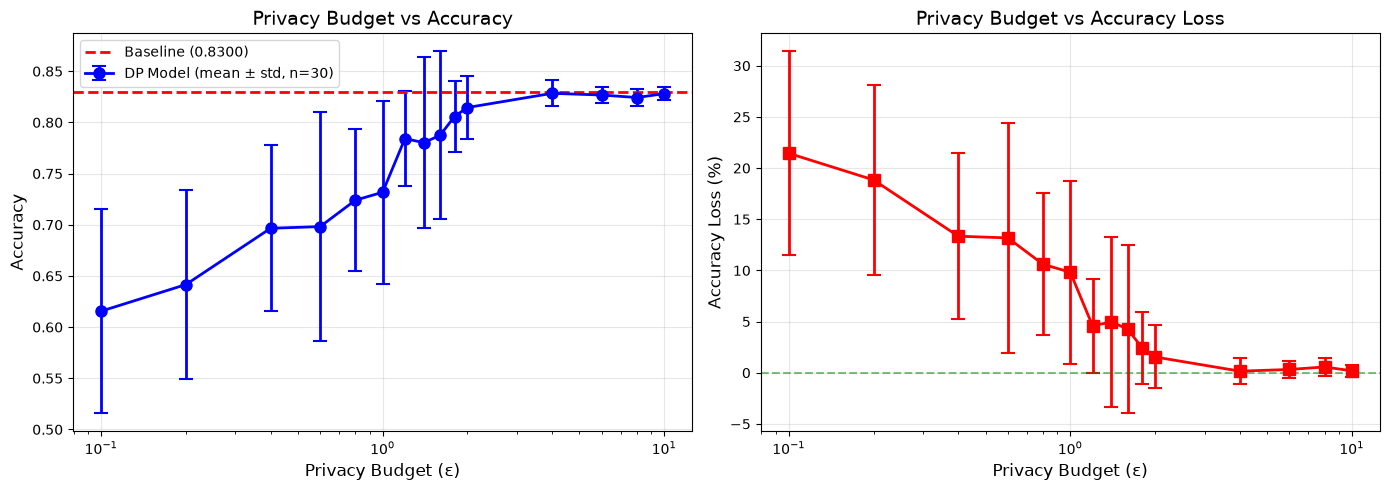

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.errorbar(results_df['epsilon'], results_df['accuracy_mean'],
    yerr=results_df['accuracy_std'], fmt='bo-', linewidth=2, markersize=8, capsize=5, capthick=1.5,
    label=f'DP Model (mean \u00b1 std, n={N_RUNS})')
if baseline_accuracy is not None:
    ax1.axhline(y=baseline_accuracy, color='r', linestyle='--', linewidth=2, label=f'Baseline ({baseline_accuracy:.4f})')
ax1.set_xlabel('Privacy Budget (\u03b5)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Privacy Budget vs Accuracy', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

if baseline_accuracy is not None:
    ax2 = axes[1]
    ax2.errorbar(results_df['epsilon'], results_df['accuracy_loss_pct'],
        yerr=results_df['accuracy_std'] * 100, fmt='rs-', linewidth=2, markersize=8, capsize=5, capthick=1.5)
    ax2.set_xlabel('Privacy Budget (\u03b5)', fontsize=12)
    ax2.set_ylabel('Accuracy Loss (%)', fontsize=12)
    ax2.set_title('Privacy Budget vs Accuracy Loss', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    ax2.axhline(y=0, color='g', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('output/privacy_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

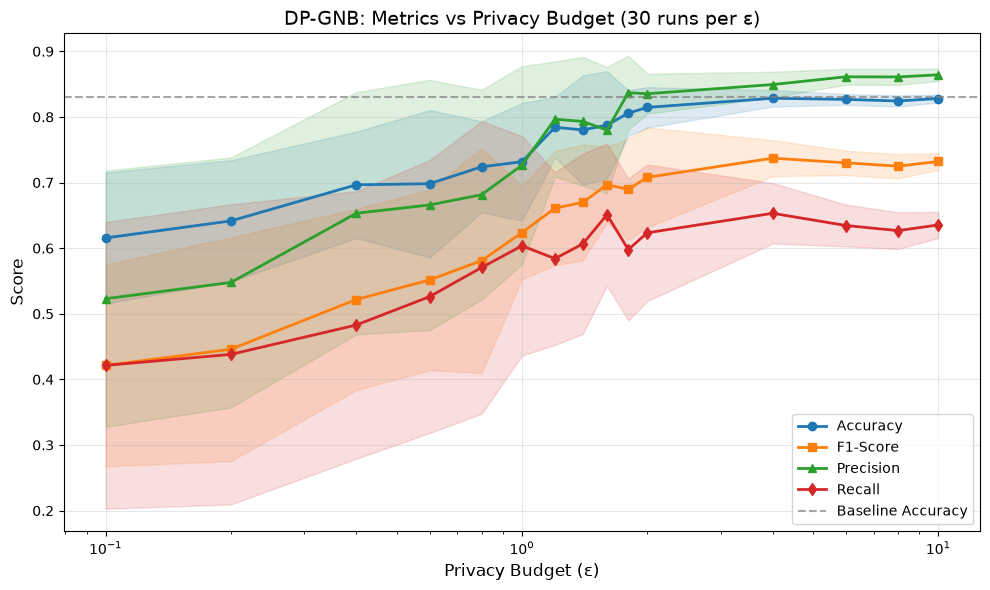

In [9]:
plt.figure(figsize=(10, 6))
metrics = [
    ('accuracy_mean', 'accuracy_std', 'Accuracy', 'o-'),
    ('f1_score_mean', 'f1_score_std', 'F1-Score', 's-'),
    ('precision_mean', 'precision_std', 'Precision', '^-'),
    ('recall_mean', 'recall_std', 'Recall', 'd-'),
]
for mean_col, std_col, label, fmt in metrics:
    mean_vals = results_df[mean_col].values
    std_vals = results_df[std_col].values
    eps_vals = results_df['epsilon'].values
    line = plt.plot(eps_vals, mean_vals, fmt, label=label, linewidth=2)
    color = line[0].get_color()
    plt.fill_between(eps_vals, mean_vals - std_vals, mean_vals + std_vals, alpha=0.15, color=color)
if baseline_accuracy is not None:
    plt.axhline(y=baseline_accuracy, color='gray', linestyle='--', alpha=0.7, label='Baseline Accuracy')
plt.xlabel('Privacy Budget (\u03b5)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title(f'DP-GNB: Metrics vs Privacy Budget ({N_RUNS} runs per \u03b5)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.savefig('output/all_metrics_vs_epsilon.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Summary

In [10]:
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
if baseline_accuracy is not None:
    print(f"\nBaseline (Standard GNB) Accuracy: {baseline_accuracy:.4f}")
print(f"\nDP-GNB Results ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))


FINAL SUMMARY

Baseline (Standard GNB) Accuracy: 0.8300

DP-GNB Results (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.615556      0.099764       0.421352      0.153933        0.522947       0.195214     0.421321    0.218453                0.575475               0.082263      0.620156     0.106299         0.002070        0.000191            0.214444          21.444444
     0.2       0.641556      0.092583       0.445990      0.170406        0.547747       0.190454     0.438138    0.228700                0.599581               0.081478      0.645707     0.132939         0.001898        0.000099            0.188444          18.844444
     0.4       0.696556      0.081087       0.521741      0.138061        0.653186       0.184654